# Softmax Regression
> iris.csv

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder

In [4]:
df = sns.load_dataset('iris')
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [6]:
encoder = LabelEncoder()
df['species'] = encoder.fit_transform(df['species']) # encoding class to number
df.sample(10)

,sepal_length,sepal_width,petal_length,petal_width,species
135,7.7,3.0,6.1,2.3,2
128,6.4,2.8,5.6,2.1,2
89,5.5,2.5,4.0,1.3,1
98,5.1,2.5,3.0,1.1,1
65,6.7,3.1,4.4,1.4,1
76,6.8,2.8,4.8,1.4,1
122,7.7,2.8,6.7,2.0,2
54,6.5,2.8,4.6,1.5,1
9,4.9,3.1,1.5,0.1,0
97,6.2,2.9,4.3,1.3,1


In [8]:
df = df[['sepal_length','petal_length','species']]
df.sample(5)

,sepal_length,petal_length,species
6,4.6,1.4,0
136,6.3,5.6,2
71,6.1,4.0,1
50,7.0,4.7,1
118,7.7,6.9,2


In [9]:
# features and target
x = df.iloc[:, 0:2]
y = df.iloc[:, -1]

# data split
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2, random_state=42)

In [10]:
# model train
sr = LogisticRegression(multi_class='multinomial')
sr.fit(x_train, y_train)
y_Pred = sr.predict(x_test)

/Users/lucifer/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


In [11]:
# print intercept and coef
print('intercept: ',sr.intercept_)
print('coef: ',sr.coef_)

intercept:  [ 11.60627322   0.68022084 -12.28649405]
coef:  [[-0.24796514 -2.91791583]
 [ 0.51846232 -0.37274858]
 [-0.27049718  3.29066441]]


In [12]:
# accuracy score
print('accuracy_score:',accuracy_score(y_test, y_Pred))

accuracy_score: 1.0


<Axes: >

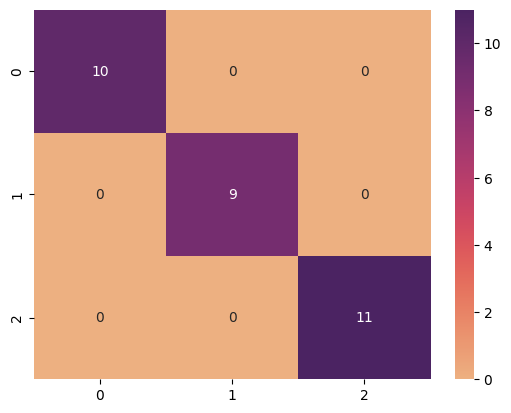

In [21]:
sns.heatmap(confusion_matrix(y_test, y_Pred), annot=True, cmap = 'flare')

In [24]:
# user input query
user_ip = np.array([[3.4, 2.7]]) # sepal_length and petal_length respectively
sr.predict_proba(user_ip)

# 👇 here are the respective probability for each class

/Users/lucifer/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


array([[8.09242380e-01, 1.90157191e-01, 6.00428887e-04]])

In [25]:
# actual prediction of class
sr.predict(user_ip)

/Users/lucifer/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


array([0])

/Users/lucifer/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


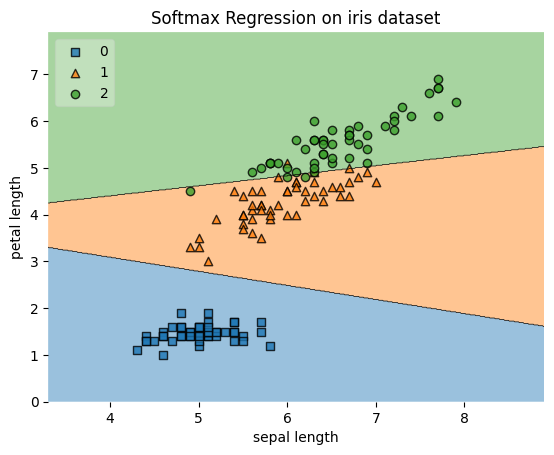

In [27]:
# plotting decision boundries
from mlxtend.plotting import plot_decision_regions

plot_decision_regions(x.values, y.values, sr, legend = 2)
plt.xlabel('sepal length')
plt.ylabel('petal length')
plt.title('Softmax Regression on iris dataset')
plt.show()